In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap

In [96]:
dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [97]:
dataset.shape

(23479, 500)

In [98]:
dataset.iloc[45:55, 145:165]

,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164
45,14819,14804,14682,13960,12914,12132,12039,12364,12922,13402,13753,14060,14220,14340,14439,14523,14521,14590,14639,14642
46,14792,14685,14599,14615,14609,14668,14705,14743,14756,14788,14794,14795,14802,14811,14811,14810,14814,14820,14823,14823
47,14822,14807,14667,14202,13688,13391,13447,13753,14074,14375,14488,14540,14593,14657,14729,14746,14748,14728,14748,14769
48,14809,14732,14555,14360,14247,14315,14454,14571,14657,14720,14750,14750,14783,14786,14798,14809,14815,14811,14808,14811
49,14821,14787,14680,14556,14465,14539,14645,14727,14748,14769,14778,14791,14792,14785,14801,14798,14803,14801,14822,14804
50,14817,14783,14743,14411,12305,8667,5625,4760,6175,8449,10265,11758,12678,13234,13630,13971,14162,14311,14372,14461
51,14814,14808,14766,14411,13755,13110,12838,13041,13372,13684,14046,14192,14338,14402,14470,14554,14578,14626,14652,14652
52,14806,14747,14524,14110,13890,13995,14188,14334,14488,14585,14644,14692,14748,14762,14752,14790,14776,14746,14785,14802
53,14812,14756,14642,14425,14326,14329,14453,14484,14554,14625,14681,14707,14711,14736,14737,14768,14742,14763,14774,14769
54,14795,14788,14657,14003,13255,12973,13060,13574,13932,14200,14395,14474,14575,14633,14687,14721,14752,14770,14764,14769


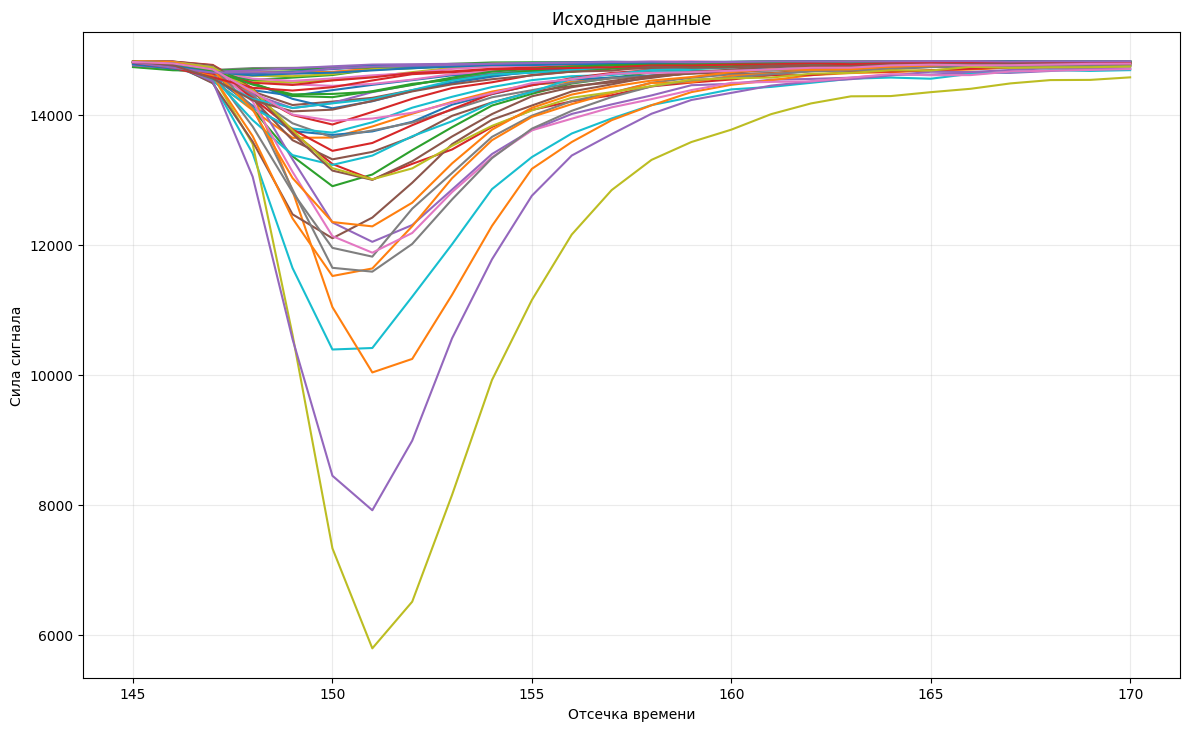

In [99]:
plt.figure(figsize=(12, 12/1.618))

plt.title("Исходные данные")
plt.xlabel("Отсечка времени")
plt.ylabel("Сила сигнала")

for i in range(0, 23001, 500):
    plt.plot(np.arange(145, 171), dataset.iloc[i, 145:171])

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [100]:
dataset = (2**14) - dataset - 1560
dataset.iloc[:5, 145:165]

,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164
0,10,61,261,446,533,446,364,292,217,194,143,92,83,76,68,52,45,34,32,25
1,5,12,151,644,1389,1903,1785,1436,1072,768,551,398,288,204,151,124,88,61,62,74
2,14,42,266,937,1883,2484,2560,2044,1500,1065,722,532,372,288,203,194,136,136,130,104
3,0,44,194,397,566,527,464,345,250,188,156,124,84,61,52,45,26,45,42,44
4,10,34,193,820,1528,1796,1630,1326,949,663,468,337,253,215,178,112,77,73,69,57


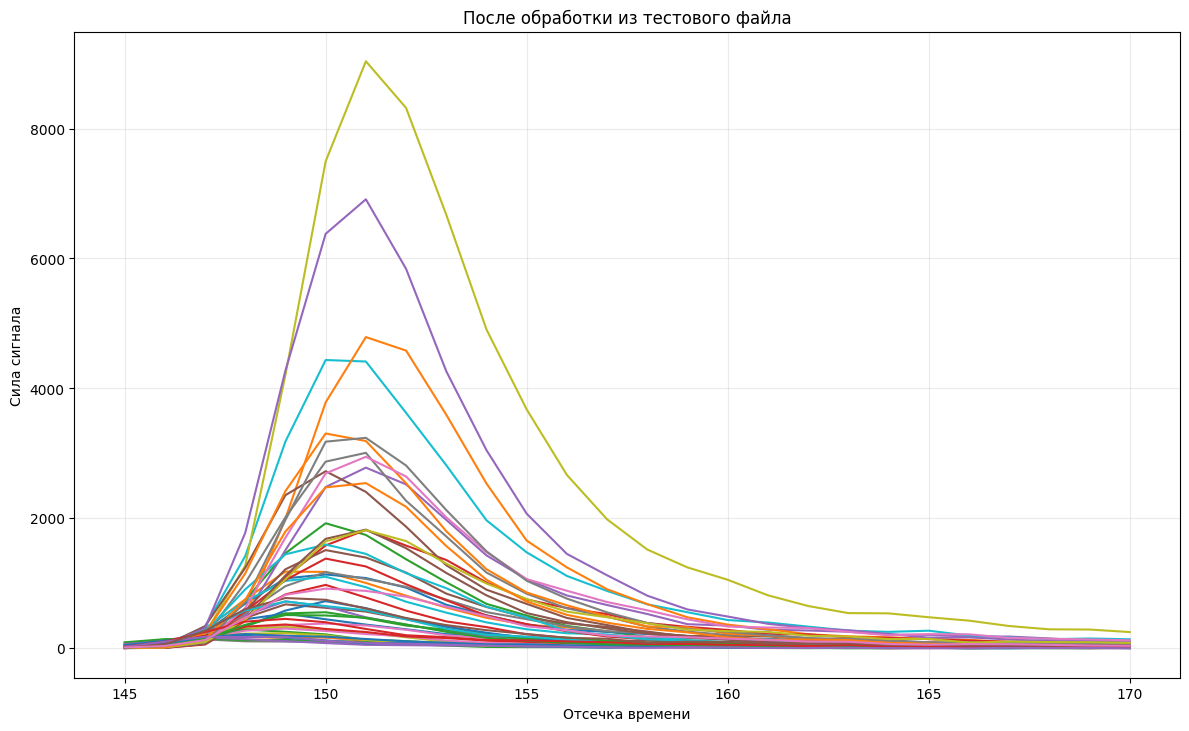

In [101]:
plt.figure(figsize=(12, 12/1.618))

plt.title("После обработки из тестового файла")
plt.xlabel("Отсечка времени")
plt.ylabel("Сила сигнала")

for i in range(0, 23001, 500):
    plt.plot(np.arange(145, 171), dataset.iloc[i, 145:171])

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [102]:
signals_array = dataset.values.astype(float)

amplitudes = []
volumes = []
psd = []

mean_leftTail = np.mean(signals_array[:, :50], axis=1)
noise = 3 * np.std(signals_array[:, :50], axis=1)

for i in range(len(signals_array)):
    signal = signals_array[i].copy()
    
    signal = signal - mean_leftTail[i]
    noise_forSignal = noise[i]
    
    max_index = np.argmax(signal)
    
    end_index = max_index + np.where(signal[max_index:] < noise_forSignal)[0][0]
    signal_informative = signal[max_index:end_index]
    
    amplitude = np.max(signal_informative) - np.min(signal_informative)
    volume = np.trapezoid(signal_informative)
    
    short_gate_len = min(5, len(signal_informative))
    short_gate = np.trapezoid(signal_informative[:short_gate_len])
    psd_value = (volume - short_gate) / volume if volume != 0 else 0
    
    amplitudes.append(amplitude)
    volumes.append(volume)
    psd.append(psd_value)

dataset["amplitude"] = amplitudes
dataset["volume"] = volumes
dataset["psd"] = psd

In [103]:
dataset[["amplitude", "volume", "psd"]]

,amplitude,volume,psd
0,512.0,2570.54,0.429334
1,1892.0,8480.76,0.337038
2,2550.0,9241.50,0.324612
3,553.0,3076.92,0.435071
4,1784.0,7684.90,0.333121
...,...,...,...
23474,496.0,2294.46,0.338685
23475,5752.0,32713.08,0.456109
23476,4989.0,27955.02,0.492879
23477,1446.0,8138.16,0.485061


In [104]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

psd_data = dataset["psd"].values

kde = gaussian_kde(psd_data, bw_method="scott")
x_kde = np.linspace(min(psd_data), max(psd_data), 1000)
y_kde = kde(x_kde)

peaks, peak_properties = find_peaks(y_kde, height=6.0)
peaks = peaks[np.argsort(y_kde[peaks])[-2:]]
peaks = np.sort(peaks)

search_indices = np.where((x_kde > x_kde[peaks[0]]) & (x_kde < x_kde[peaks[1]]))[0]
    
min_idx = search_indices[np.argmin(y_kde[search_indices])]
intersection_point = x_kde[min_idx]

print(f"Точка пересечения (минимум): {intersection_point:.5f}")


Точка пересечения (минимум): 0.38046


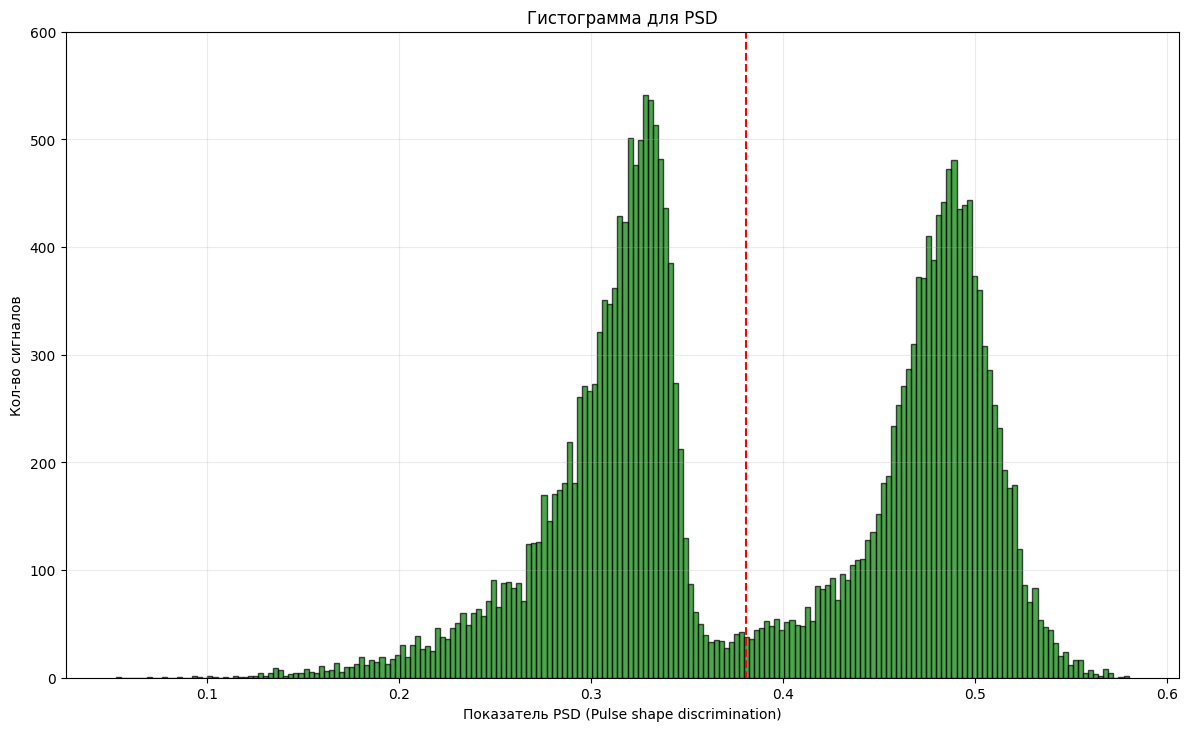

In [105]:
plt.figure(figsize=(12, 12/1.618))

plt.title("Гистограмма для PSD")
plt.xlabel("Показатель PSD (Pulse shape discrimination)")
plt.ylabel("Кол-во сигналов")

plt.hist(dataset["psd"], bins=200, alpha=0.7, color="green", edgecolor="black")
plt.plot([0.38046, 0.38046], [-1, 1000], "--", color="red")

plt.ylim(0, 600)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

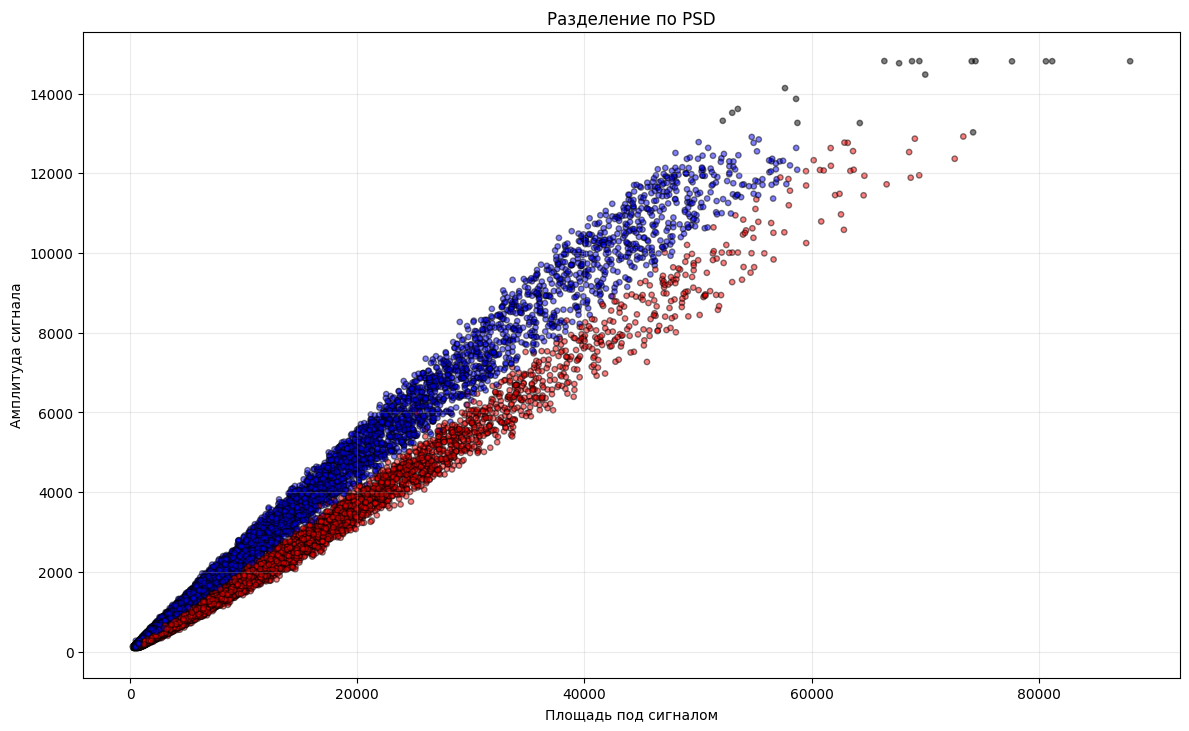

In [106]:
labels = (dataset["psd"] < 0.38046).astype(int)
labels[dataset["amplitude"] > 13000] = 2

plt.figure(figsize=(12, 12/1.618))

plt.title("Разделение по PSD")
plt.xlabel("Площадь под сигналом")
plt.ylabel("Амплитуда сигнала")

plt.scatter(
    volumes, amplitudes, c=labels,
    cmap=ListedColormap(["red", "blue", "black"]),
    s=15, edgecolor="black", alpha=0.50)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [107]:
results = pd.DataFrame({
    "index": range(len(dataset)),
    "cluster": labels
}).sort_values(by="cluster", kind="stable")
results.to_csv("sub.csv", index=False)